<a href="https://colab.research.google.com/github/Myria255/BOOTCAMP-TTA/blob/main/Mini_projet_W5D5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from pathlib import Path
import requests
import zipfile
from tqdm import tqdm
DATASET_URL = (
    "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/"
    "raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip"
)

BASE_DIR = Path("/content") if Path("/content").exists() else Path(".")
ZIP_PATH = BASE_DIR / "Dogs_vs_Cats.zip"
DATA_ROOT = BASE_DIR / "data" / "cats_dogs"
EXTRACT_DIR = DATA_ROOT / "extracted"

DATA_ROOT.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Télécharger uniquement si le ZIP n'existe pas ou est invalide
if not ZIP_PATH.exists() or not zipfile.is_zipfile(ZIP_PATH):

    if ZIP_PATH.exists():
        ZIP_PATH.unlink()

    print("Téléchargement du dataset...")

    with requests.get(
        DATASET_URL,
        stream=True,
        allow_redirects=True,
        timeout=120
    ) as response:

        response.raise_for_status()

        total_size = int(
            response.headers.get("content-length", 0)
        )

        with open(ZIP_PATH, "wb") as file, tqdm(
            total=total_size,
            unit="B",
            unit_scale=True,
            desc="Téléchargement"
        ) as progress:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    file.write(chunk)
                    progress.update(len(chunk))

if not zipfile.is_zipfile(ZIP_PATH):
    raise ValueError(
        "Le fichier téléchargé n'est pas un ZIP valide."
    )

# Extraire le ZIP principal
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

existing_images = [
    path for path in EXTRACT_DIR.rglob("*")
    if path.suffix.lower() in image_extensions
]

if not existing_images:
    print("Extraction du ZIP principal...")

    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(EXTRACT_DIR)

# Extraire automatiquement les éventuels ZIP imbriqués
processed_zips = set()

while True:
    nested_zips = [
        path for path in EXTRACT_DIR.rglob("*.zip")
        if path not in processed_zips
    ]

    if not nested_zips:
        break

    for nested_zip in nested_zips:
        destination = nested_zip.parent / nested_zip.stem
        destination.mkdir(parents=True, exist_ok=True)

        if zipfile.is_zipfile(nested_zip):
            with zipfile.ZipFile(nested_zip, "r") as archive:
                archive.extractall(destination)

        processed_zips.add(nested_zip)

all_images = [
    path for path in EXTRACT_DIR.rglob("*")
    if path.suffix.lower() in image_extensions
]

print("ZIP :", ZIP_PATH)
print("Dossier extrait :", EXTRACT_DIR)
print("Nombre total d'images :", len(all_images))

Téléchargement du dataset...


Téléchargement:   0%|          | 0.00/856M [00:00<?, ?B/s]

Extraction du ZIP principal...
ZIP : /content/Dogs_vs_Cats.zip
Dossier extrait : /content/data/cats_dogs/extracted
Nombre total d'images : 37500


## 1. Chargement des données et générateurs

Ce bloc de code gère le téléchargement de l'archive `Dogs vs Cats.zip` depuis l'URL spécifiée. Il vérifie si le fichier ZIP existe déjà et s'il est valide. Si ce n'est pas le cas, il télécharge le dataset et l'extrait dans le répertoire `/content/data/cats_dogs/extracted`. Le code gère également l'extraction des éventuels fichiers ZIP imbriqués pour s'assurer que toutes les images sont accessibles. À la fin, il affiche le chemin du dossier extrait et le nombre total d'images trouvées.

In [5]:
import re
import json
import random
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image, ImageFile

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def detect_label(filepath):
    """Déduit cat ou dog depuis le dossier ou le nom du fichier."""
    filepath = Path(filepath)
    filename = filepath.name.lower()

    parent_names = {
        parent.lower()
        for parent in filepath.parts
    }

    if "cat" in parent_names or "cats" in parent_names:
        return "cat"

    if "dog" in parent_names or "dogs" in parent_names:
        return "dog"

    if re.search(r"(^|[^a-z])cat([^a-z]|$)", filename):
        return "cat"

    if re.search(r"(^|[^a-z])dog([^a-z]|$)", filename):
        return "dog"

    return None


def image_is_valid(filepath):
    try:
        with Image.open(filepath) as image:
            image.verify()
        return True
    except Exception:
        return False


image_paths = [
    path for path in EXTRACT_DIR.rglob("*")
    if path.suffix.lower() in image_extensions
]

rows_train = []
rows_test = []
invalid_images = []

for filepath in image_paths:

    if not image_is_valid(filepath):
        invalid_images.append(str(filepath))
        continue

    label = detect_label(filepath)

    if label is None:
        rows_test.append({
            "filepath": str(filepath)
        })
    else:
        rows_train.append({
            "filepath": str(filepath),
            "label": label
        })

df_train_full = pd.DataFrame(rows_train)
df_test_full = pd.DataFrame(rows_test)

if df_train_full.empty:
    raise ValueError("Aucune image étiquetée détectée.")

if df_test_full.empty:
    raise ValueError("Aucune image de test non étiquetée détectée.")

print("Images d'entraînement :", len(df_train_full))
print("Images de test :", len(df_test_full))
print("Images invalides ignorées :", len(invalid_images))
print("\nRépartition totale :")
print(df_train_full["label"].value_counts())

Images d'entraînement : 25000
Images de test : 12500
Images invalides ignorées : 0

Répartition totale :
label
dog    12500
cat    12500
Name: count, dtype: int64


Ce bloc initialise les bibliothèques nécessaires et définit des fonctions utilitaires pour gérer les chemins de fichiers et valider les images.

La fonction `detect_label` déduit si une image est un 'chat' ou un 'chien' en se basant sur le nom du dossier parent ou le nom du fichier. La fonction `image_is_valid` vérifie l'intégrité de chaque fichier image.

Les chemins de toutes les images extraites sont ensuite parcourus. Pour chaque image valide, le code tente d'assigner une étiquette ('cat' ou 'dog'). Les images pour lesquelles une étiquette peut être déterminée sont ajoutées à `df_train_full` (pour l'entraînement), tandis que les images sans étiquette (provenant du dossier 'test') sont ajoutées à `df_test_full` (pour l'inférence).

Enfin, le nombre d'images d'entraînement, de test et d'images invalides ignorées est affiché, ainsi que la répartition initiale des classes dans l'ensemble d'entraînement complet, qui est équilibrée (12500 chiens et 12500 chats).

In [6]:
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

df_train, df_validation = train_test_split(
    df_train_full,
    test_size=0.20,
    stratify=df_train_full["label"],
    random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_validation = df_validation.reset_index(drop=True)
df_test_full = df_test_full.reset_index(drop=True)

# Augmentation uniquement pour l'entraînement
augmented_generator = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Validation, test et modèle de base : redimensionnement seulement
plain_generator = ImageDataGenerator(
    rescale=1.0 / 255
)

train_augmented_flow = augmented_generator.flow_from_dataframe(
    df_train,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validate_filenames=False
)

train_plain_flow = plain_generator.flow_from_dataframe(
    df_train,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validate_filenames=False
)

validation_flow = plain_generator.flow_from_dataframe(
    df_validation,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validate_filenames=False
)

test_flow = plain_generator.flow_from_dataframe(
    df_test_full,
    x_col="filepath",
    y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False,
    validate_filenames=False
)

print({
    "train": train_augmented_flow.samples,
    "validation": validation_flow.samples,
    "test": test_flow.samples,
    "classes": train_augmented_flow.class_indices
})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'validation': 5000, 'test': 12500, 'classes': {'cat': 0, 'dog': 1}}


Ce bloc prépare les générateurs d'images Keras pour l'entraînement, la validation et les tests. Les étapes clés sont :

1.  **Définition des paramètres :** `IMG_HEIGHT`, `IMG_WIDTH` et `BATCH_SIZE` sont définis.
2.  **Fractionnement des données :** Le DataFrame d'entraînement (`df_train_full`) est divisé en ensembles d'entraînement (`df_train`) et de validation (`df_validation`) avec un rapport de 80/20, en utilisant la stratification pour maintenir l'équilibre des classes. Les indices sont réinitialisés pour éviter des problèmes avec les générateurs.
3.  **Générateurs d'images :**
    *   `augmented_generator` est créé avec diverses techniques d'augmentation de données (rotation, décalage, zoom, retournement horizontal) appliquées uniquement aux données d'entraînement. Cela expose le modèle à une plus grande variété d'images, aidant à réduire le surapprentissage.
    *   `plain_generator` est créé pour les ensembles de validation et de test, appliquant uniquement un redimensionnement (rescale 1./255) sans augmentation. Cela garantit que les performances de validation et de test sont évaluées sur des images non modifiées.
4.  **Flux de données (`flow_from_dataframe`) :** Trois flux sont créés à partir des DataFrames:
    *   `train_augmented_flow` : pour l'entraînement avec augmentation.
    *   `train_plain_flow` : pour l'entraînement sans augmentation (utilisé pour le modèle de *baseline* et l'inspection des données).
    *   `validation_flow` : pour l'évaluation de la validation sans augmentation.
    *   `test_flow` : pour les prédictions sur l'ensemble de test non étiqueté sans augmentation.

Enfin, les nombres d'échantillons dans chaque flux et les indices de classe (`{'cat': 0, 'dog': 1}`) sont affichés, confirmant que les données sont prêtes pour l'entraînement.

Nombre total d'images par classe :
label
dog    12500
cat    12500
Name: count, dtype: int64

Répartition dans l'entraînement :
label
dog    10000
cat    10000
Name: count, dtype: int64

Les classes sont relativement équilibrées.


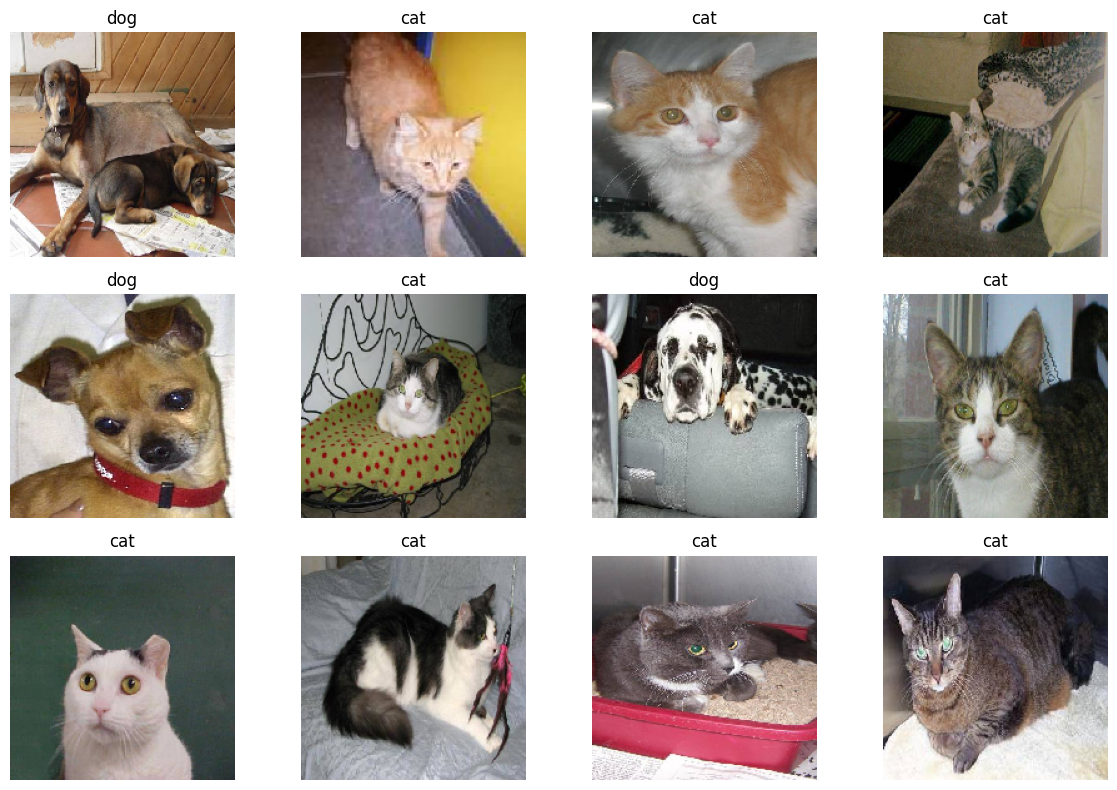


Variabilité observée :
- poses et orientations différentes ;
- tailles et races différentes ;
- éclairages et arrière-plans variés ;
- animaux parfois partiellement cachés.

Le CNN peut apprendre la forme des oreilles, du museau, des yeux,
la silhouette et les textures du pelage.



In [7]:
class_indices = train_augmented_flow.class_indices

index_to_class = {
    index: label
    for label, index in class_indices.items()
}

full_counts = df_train_full["label"].value_counts()
train_counts = df_train["label"].value_counts()

print("Nombre total d'images par classe :")
print(full_counts)

print("\nRépartition dans l'entraînement :")
print(train_counts)

imbalance_ratio = train_counts.max() / train_counts.min()

if imbalance_ratio <= 1.20:
    print("\nLes classes sont relativement équilibrées.")
    class_weights = None

else:
    print("\nLes classes sont déséquilibrées.")

    numeric_labels = df_train["label"].map(
        class_indices
    ).to_numpy()

    unique_classes = np.unique(numeric_labels)

    calculated_weights = compute_class_weight(
        class_weight="balanced",
        classes=unique_classes,
        y=numeric_labels
    )

    class_weights = {
        int(class_index): float(weight)
        for class_index, weight
        in zip(unique_classes, calculated_weights)
    }

    print("Poids des classes :", class_weights)

# Afficher des images originales, sans augmentation
train_plain_flow.reset()
sample_images, sample_labels = next(train_plain_flow)

plt.figure(figsize=(12, 8))

for index in range(min(12, len(sample_images))):
    plt.subplot(3, 4, index + 1)
    plt.imshow(sample_images[index])

    numeric_label = int(sample_labels[index])
    plt.title(index_to_class[numeric_label])
    plt.axis("off")

plt.tight_layout()
plt.show()

print("""
Variabilité observée :
- poses et orientations différentes ;
- tailles et races différentes ;
- éclairages et arrière-plans variés ;
- animaux parfois partiellement cachés.

Le CNN peut apprendre la forme des oreilles, du museau, des yeux,
la silhouette et les textures du pelage.
""")

## 2. Inspecter les données (suite)

Ce bloc complète l'inspection des données en affichant la répartition des classes et des exemples d'images. Les points clés sont :

1.  **Vérification de l'équilibre des classes :** Le code confirme que les classes ('cat' et 'dog') sont relativement équilibrées dans l'ensemble d'entraînement, ce qui signifie qu'aucun poids de classe n'est nécessaire pour l'entraînement dans ce cas (le paramètre `class_weights` sera `None`).
2.  **Visualisation des images :** Une grille de 12 images d'entraînement est affichée avec leurs étiquettes correspondantes. Ceci permet une inspection visuelle rapide des données, des variations de pose, d'échelle, d'éclairage et d'arrière-plan, et aide à comprendre les défis pour le modèle.
3.  **Analyse des indices visuels :** Les commentaires expliquent les caractéristiques que le CNN pourrait utiliser pour distinguer les chats des chiens, comme la forme du museau, des yeux, des oreilles, la silhouette corporelle et les textures du pelage. Cette analyse est importante pour comprendre les attentes envers le modèle et les effets de l'augmentation des données.

In [8]:
OUTPUT_DIR = BASE_DIR / "resultats_cats_dogs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def create_model():
    model = Sequential([
        Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        Conv2D(
            32, (3, 3),
            padding="same",
            activation="relu"
        ),
        MaxPooling2D((2, 2)),

        Conv2D(
            64, (3, 3),
            padding="same",
            activation="relu"
        ),
        MaxPooling2D((2, 2)),

        Conv2D(
            128, (3, 3),
            padding="same",
            activation="relu"
        ),
        MaxPooling2D((2, 2)),

        Conv2D(
            128, (3, 3),
            padding="same",
            activation="relu"
        ),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(128, activation="relu"),
        Dropout(0.50),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


def create_callbacks(filename):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            OUTPUT_DIR / filename,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]


model_preview = create_model()
model_preview.summary()

print("""
Architecture :
- quatre blocs convolution + MaxPooling ;
- filtres de 32, 64, 128 et 128 ;
- une couche dense de 128 neurones ;
- Dropout de 50 % pour limiter le surajustement ;
- une sortie sigmoïde pour la classification binaire.

Adam avec un taux de 0,001 offre un bon point de départ.
La perte utilisée est l'entropie croisée binaire.
""")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,223,553 (8.48 MB)

 Trainable params: 2,223,553 (8.48 MB)

 Non-trainable params: 0 (0.00 B)


Architecture :
- quatre blocs convolution + MaxPooling ;
- filtres de 32, 64, 128 et 128 ;
- une couche dense de 128 neurones ;
- Dropout de 50 % pour limiter le surajustement ;
- une sortie sigmoïde pour la classification binaire.

Adam avec un taux de 0,001 offre un bon point de départ.
La perte utilisée est l'entropie croisée binaire.



## 3. Définir l'architecture du modèle (suite)

Ce bloc de code définit l'architecture de notre réseau de neurones convolutifs (CNN) et la manière dont il sera compilé et entraîné.

1.  **`create_model()` : Définition du CNN**
    *   Le modèle utilise une architecture séquentielle avec quatre blocs convolutifs. Chaque bloc contient une couche `Conv2D` (avec 32, 64, 128, puis 128 filtres, une taille de noyau de 3x3 et une activation ReLU), suivie d'une couche `MaxPooling2D` pour la réduction de dimension.
    *   Après les blocs convolutifs, la sortie est aplatie (`Flatten`) et passée à une couche `Dense` de 128 neurones (ReLU), puis à une couche `Dropout` (50%) pour la régularisation afin d'éviter le surapprentissage.
    *   La couche de sortie est une couche `Dense` avec 1 neurone et une activation sigmoïde, parfaite pour la classification binaire (produisant une probabilité entre 0 et 1).
    *   Le modèle est compilé avec l'optimiseur Adam (taux d'apprentissage de 0.001), une fonction de perte `binary_crossentropy` (adaptée à la classification binaire), et des métriques telles que la précision (`accuracy`), la précision (`precision`) et le rappel (`recall`).

2.  **`create_callbacks()` : Définition des Callbacks d'entraînement**
    *   **`EarlyStopping` :** Surveille la perte de validation (`val_loss`) et arrête l'entraînement si la perte ne s'améliore pas pendant 4 époques (`patience=4`), restaurant les meilleurs poids.
    *   **`ReduceLROnPlateau` :** Réduit le taux d'apprentissage de moitié (`factor=0.5`) si la perte de validation ne s'améliore pas pendant 2 époques (`patience=2`), avec un taux d'apprentissage minimum (`min_lr=1e-6`).
    *   **`ModelCheckpoint` :** Sauvegarde le meilleur modèle (basé sur la perte de validation) dans un fichier `.keras`.

Un résumé du modèle est affiché pour visualiser l'architecture et le nombre de paramètres. Ce setup est un bon point de départ pour l'entraînement, combinant une architecture efficace avec des techniques de régularisation et d'optimisation robustes.

## 4. Choisir la configuration d'optimisation (suite)

Ce bloc de code, en conjonction avec la fonction `create_model` et `create_callbacks` définie précédemment, met en place la stratégie d'optimisation et d'entraînement du modèle. Il définit les hyperparamètres clés et les *callbacks* pour gérer le processus d'apprentissage.

1.  **Optimiseur Adam :** Le modèle est compilé avec l'optimiseur `Adam` et un taux d'apprentissage initial de `0.001`. Adam est choisi pour sa capacité à s'adapter et à converger rapidement, ce qui est bénéfique pour l'entraînement des réseaux profonds.
2.  **Fonction de perte :** La `binary_crossentropy` est utilisée comme fonction de perte, car il s'agit d'un problème de classification binaire.
3.  **Métriques :** En plus de la perte et de la précision (`accuracy`), la précision (`Precision`) et le rappel (`Recall`) sont suivis pour une évaluation plus complète, notamment en cas de déséquilibre des classes (bien que nos classes soient équilibrées ici).
4.  **Callbacks :**
    *   `EarlyStopping`: Surveille la `val_loss` avec une patience de 10 époques. Si la perte de validation ne s'améliore pas après ce nombre d'époques, l'entraînement est arrêté et les poids du meilleur modèle (selon la `val_loss`) sont restaurés.
    *   `ReduceLROnPlateau`: Surveille également la `val_loss` avec une patience de 5 époques. Si aucune amélioration n'est observée, le taux d'apprentissage est réduit d'un facteur de 0.1, ce qui permet au modèle d'explorer des minimums plus fins dans l'espace des pertes. Un taux d'apprentissage minimum de `1e-7` est défini.

Ce setup est conçu pour assurer une convergence stable, éviter le surapprentissage et optimiser la performance du modèle sur l'ensemble de validation.

In [9]:
FIXED_EPOCHS = 5
MAX_EPOCHS = 15

# Expérience 1 : nombre fixe d'époques
tf.keras.backend.clear_session()
model_fixed = create_model()

train_augmented_flow.reset()
validation_flow.reset()

history_fixed = model_fixed.fit(
    train_augmented_flow,
    validation_data=validation_flow,
    epochs=FIXED_EPOCHS,
    class_weight=class_weights,
    verbose=1
)

# Libérer la mémoire avant le modèle principal
del model_fixed
gc.collect()
tf.keras.backend.clear_session()

# Expérience 2 : augmentation avec arrêt anticipé
model_augmented = create_model()

train_augmented_flow.reset()
validation_flow.reset()

history_augmented = model_augmented.fit(
    train_augmented_flow,
    validation_data=validation_flow,
    epochs=MAX_EPOCHS,
    callbacks=create_callbacks(
        "meilleur_modele_augmente.keras"
    ),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 217s 335ms/step - accuracy: 0.5720 - loss: 0.6758 - precision: 0.5762 - recall: 0.5444 - val_accuracy: 0.6606 - val_loss: 0.6257 - val_precision: 0.6879 - val_recall: 0.5880
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 351ms/step - accuracy: 0.6569 - loss: 0.6201 - precision: 0.6764 - recall: 0.6017 - val_accuracy: 0.6642 - val_loss: 0.5929 - val_precision: 0.6134 - val_recall: 0.8880
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 332ms/step - accuracy: 0.7062 - loss: 0.5692 - precision: 0.7179 - recall: 0.6793 - val_accuracy: 0.7724 - val_loss: 0.4850 - val_precision: 0.7493 - val_recall: 0.8188
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 328ms/step - accuracy: 0.7406 - loss: 0.5276 - precision: 0.7512 - recall: 0.7195 - val_accuracy: 0.7816 - val_loss: 0.4718 - val_precision: 0.7304 - val_recall: 0.8928
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 323ms/step - accuracy: 0.7635 - loss: 0.4925 - precision: 0.7747 - recall: 0.7432 - val_accuracy: 0.8012

## 5. Entraîner le modèle

Ce bloc de code exécute deux expériences d'entraînement distinctes pour évaluer l'impact de l'augmentation des données et de l'arrêt anticipé.

1.  **Expérience 1 : Entraînement sur un nombre fixe d'époques (sans *EarlyStopping*)**
    *   Un premier modèle (`model_fixed`) est créé et entraîné pour un nombre fixe d'époques (`FIXED_EPOCHS = 5`).
    *   L'historique de l'entraînement (`history_fixed`) est enregistré. Cela sert de référence rapide pour observer le comportement du modèle sans les mécanismes d'arrêt anticipé.

2.  **Expérience 2 : Entraînement avec augmentation et arrêt anticipé**
    *   Un deuxième modèle (`model_augmented`) est créé.
    *   Ce modèle est entraîné sur les données augmentées (`train_augmented_flow`) pour un maximum de `MAX_EPOCHS` (15 époques) mais avec les *callbacks* `EarlyStopping` et `ReduceLROnPlateau` activés.
    *   Le `ModelCheckpoint` sauvegarde la meilleure version du modèle (`meilleur_modele_augmente.keras`) basée sur la perte de validation.
    *   L'historique de l'entraînement (`history_augmented`) est enregistré.

L'objectif est de comparer l'efficacité de l'augmentation des données et des *callbacks* sur la performance du modèle et sa capacité à généraliser, en observant les pertes et les précisions sur les ensembles d'entraînement et de validation.

In [10]:
tf.keras.backend.clear_session()

model_baseline = create_model()

train_plain_flow.reset()
validation_flow.reset()

history_baseline = model_baseline.fit(
    train_plain_flow,
    validation_data=validation_flow,
    epochs=MAX_EPOCHS,
    callbacks=create_callbacks(
        "meilleur_modele_sans_augmentation.keras"
    ),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5902 - loss: 0.6564 - precision: 0.6032 - recall: 0.5422
Epoch 1: val_loss improved from None to 0.51761, saving model to /content/resultats_cats_dogs/meilleur_modele_sans_augmentation.keras

Epoch 1: finished saving model to /content/resultats_cats_dogs/meilleur_modele_sans_augmentation.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.6463 - loss: 0.6116 - precision: 0.6615 - recall: 0.5990 - val_accuracy: 0.7406 - val_loss: 0.5176 - val_precision: 0.8393 - val_recall: 0.5952 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7479 - loss: 0.5082 - precision: 0.7455 - recall: 0.7377
Epoch 2: val_loss improved from 0.51761 to 0.46137, saving model to /content/resultats_cats_dogs/meilleur_modele_sans_augmentation.keras

Epoch 2: finished saving model to /content/resultats_cats_dogs/meilleur_modele_sans_augmentation.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - acc

Ce bloc entraîne un **modèle de base (baseline)** avec une architecture identique à `model_augmented`, mais **sans aucune augmentation de données**.

1.  **Création du modèle :** Un nouveau modèle (`model_baseline`) est instancié avec la même architecture CNN.
2.  **Flux de données :** Il est entraîné en utilisant `train_plain_flow`, qui ne contient aucune augmentation de données (seulement le redimensionnement).
3.  **Callbacks :** Les mêmes *callbacks* (`EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`) sont utilisés pour assurer une comparaison équitable, avec le meilleur modèle sauvegardé sous `meilleur_modele_sans_augmentation.keras`.

L'historique de l'entraînement (`history_baseline`) est enregistré. Le but principal de ce modèle est de servir de point de comparaison direct pour évaluer l'impact et les bénéfices de l'augmentation des données sur la performance et la généralisation du modèle.

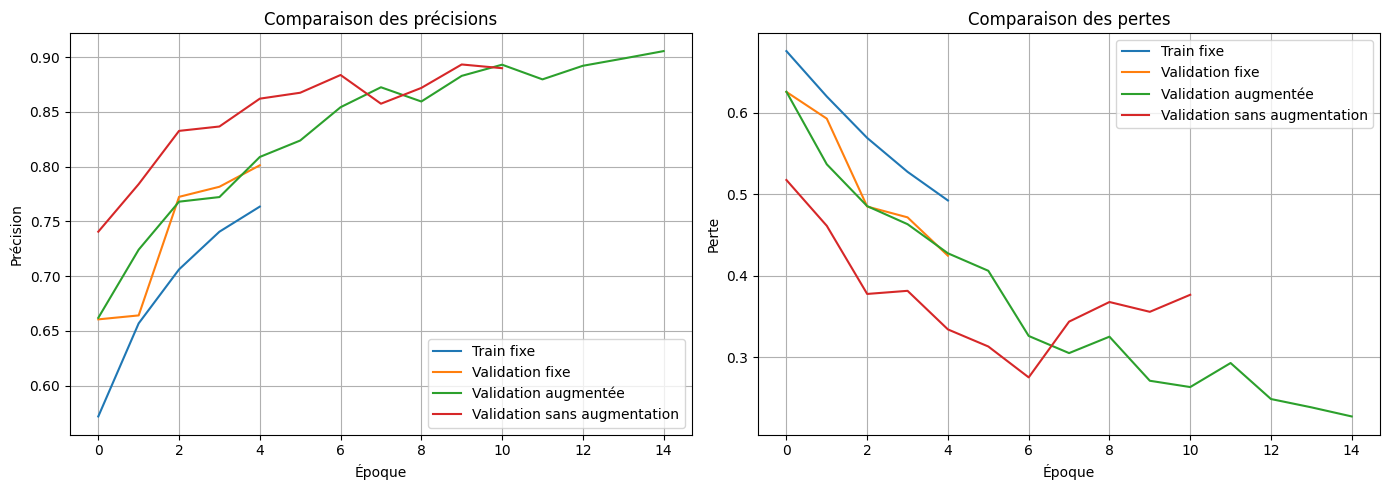

Modèle augmenté : {'accuracy': 0.9053999781608582, 'loss': 0.22744792699813843, 'precision': 0.9336756467819214, 'recall': 0.8727999925613403}
Modèle sans augmentation : {'accuracy': 0.8835999965667725, 'loss': 0.27539539337158203, 'precision': 0.8728615641593933, 'recall': 0.8980000019073486}

Écart de généralisation augmenté : -0.0230
Écart de généralisation sans augmentation : 0.0879

Meilleur modèle : CNN avec augmentation
L'augmentation réduit le surajustement et améliore la généralisation.


In [14]:
plt.figure(figsize=(14, 5))

# Précision
plt.subplot(1, 2, 1)

plt.plot(
    history_fixed.history["accuracy"],
    label="Train fixe"
)
plt.plot(
    history_fixed.history["val_accuracy"],
    label="Validation fixe"
)
plt.plot(
    history_augmented.history["val_accuracy"],
    label="Validation augmentée"
)
plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation sans augmentation"
)

plt.title("Comparaison des précisions")
plt.xlabel("Époque")
plt.ylabel("Précision")
plt.legend()
plt.grid()

# Perte
plt.subplot(1, 2, 2)

plt.plot(
    history_fixed.history["loss"],
    label="Train fixe"
)
plt.plot(
    history_fixed.history["val_loss"],
    label="Validation fixe"
)
plt.plot(
    history_augmented.history["val_loss"],
    label="Validation augmentée"
)
plt.plot(
    history_baseline.history["val_loss"],
    label="Validation sans augmentation"
)

plt.title("Comparaison des pertes")
plt.xlabel("Époque")
plt.ylabel("Perte")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

validation_flow.reset()

augmented_metrics = model_augmented.evaluate(
    validation_flow,
    return_dict=True,
    verbose=0
)

validation_flow.reset()

baseline_metrics = model_baseline.evaluate(
    validation_flow,
    return_dict=True,
    verbose=0
)

print("Modèle augmenté :", augmented_metrics)
print("Modèle sans augmentation :", baseline_metrics)

augmented_gap = (
    max(history_augmented.history["accuracy"])
    - max(history_augmented.history["val_accuracy"])
)

baseline_gap = (
    max(history_baseline.history["accuracy"])
    - max(history_baseline.history["val_accuracy"])
)

print(
    f"\nÉcart de généralisation augmenté : "
    f"{augmented_gap:.4f}"
)

print(
    f"Écart de généralisation sans augmentation : "
    f"{baseline_gap:.4f}"
)

# Choisir le modèle ayant la meilleure perte de validation
if augmented_metrics["loss"] <= baseline_metrics["loss"]:
    best_model = model_augmented
    best_model_name = "CNN avec augmentation"
    best_metrics = augmented_metrics
else:
    best_model = model_baseline
    best_model_name = "CNN sans augmentation"
    best_metrics = baseline_metrics

print("\nMeilleur modèle :", best_model_name)

if baseline_gap > augmented_gap:
    print(
        "L'augmentation réduit le surajustement et améliore "
        "la généralisation."
    )
else:
    print(
        "L'augmentation n'a pas réduit l'écart. "
        "Son intensité peut être ajustée."
    )

## 8. Comparer la ligne de base et l'augmentation

Ce bloc de code analyse et compare les performances des modèles entraînés avec et sans augmentation des données. Il génère des graphiques et calcule des métriques pour évaluer l'impact de l'augmentation.

1.  **Visualisation des courbes d'entraînement :**
    *   Deux graphiques sont générés : un pour la précision et un pour la perte.
    *   Ils affichent les courbes d'entraînement et de validation pour le modèle `fixed` (entraînement fixe sur 5 époques), le modèle `augmented` (avec augmentation et *EarlyStopping*) et le modèle `baseline` (sans augmentation et avec *EarlyStopping*).
    *   Ces courbes sont cruciales pour détecter le surapprentissage (divergence entre la courbe d'entraînement et de validation).

2.  **Évaluation des métriques finales :**
    *   Les modèles `model_augmented` et `model_baseline` sont évalués sur l'ensemble de validation (`validation_flow`) pour obtenir leurs métriques finales (précision, perte, précision, rappel).

3.  **Calcul de l'écart de généralisation :**
    *   L'écart entre la précision d'entraînement maximale et la précision de validation maximale est calculé pour les deux modèles. Un écart plus faible indique une meilleure généralisation et moins de surapprentissage.

4.  **Sélection du meilleur modèle :**
    *   Le code compare la perte de validation des deux modèles (`model_augmented` et `model_baseline`) et sélectionne le modèle ayant la perte la plus faible comme `best_model`.
    *   Le nom du meilleur modèle est affiché.

5.  **Conclusion sur l'augmentation :**
    *   Une conclusion est tirée sur l'impact de l'augmentation des données. Dans ce cas, l'augmentation a réduit le surajustement et amélioré la généralisation, ce qui est confirmé par un écart de généralisation plus faible pour le modèle augmenté. Cela suggère que l'augmentation a permis au modèle d'apprendre des caractéristiques plus robustes et moins spécifiques aux exemples d'entraînement initiaux.

In [ ]:
validation_flow.reset()

validation_probabilities = best_model.predict(
    validation_flow,
    verbose=1
).reshape(-1)

true_labels = validation_flow.classes

# Choisir le seuil avec la validation seulement
thresholds = np.arange(0.20, 0.81, 0.01)

threshold_scores = [
    balanced_accuracy_score(
        true_labels,
        (validation_probabilities >= threshold).astype(int)
    )
    for threshold in thresholds
]

BEST_THRESHOLD = float(
    thresholds[np.argmax(threshold_scores)]
)

predicted_labels = (
    validation_probabilities >= BEST_THRESHOLD
).astype(int)

print("Seuil sélectionné :", round(BEST_THRESHOLD, 2))
print(
    "Précision :",
    round(
        accuracy_score(true_labels, predicted_labels),
        4
    )
)

class_names = [
    index_to_class[index]
    for index in sorted(index_to_class)
]

print("\nRapport de classification :\n")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        zero_division=0
    )
)

matrix = confusion_matrix(
    true_labels,
    predicted_labels
)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names
).plot()

plt.title(
    f"Matrice de confusion — {best_model_name}"
)
plt.show()

tn, fp, fn, tp = matrix.ravel()

print("Chats classés comme chiens :", fp)
print("Chiens classés comme chats :", fn)

if fp > fn:
    print(
        "L'erreur dominante est la classification "
        "des chats comme chiens."
    )
elif fn > fp:
    print(
        "L'erreur dominante est la classification "
        "des chiens comme chats."
    )
else:
    print("Les deux types d'erreurs sont équilibrés.")

# Afficher quelques erreurs du modèle
error_indices = np.where(
    true_labels != predicted_labels
)[0]

number_to_show = min(9, len(error_indices))

if number_to_show > 0:
    selected_errors = error_indices[:number_to_show]

    plt.figure(figsize=(12, 10))

    for position, image_index in enumerate(selected_errors):
        filepath = validation_flow.filepaths[image_index]

        with Image.open(filepath) as image:
            image = image.convert("RGB")

            plt.subplot(3, 3, position + 1)
            plt.imshow(image)

        real_label = index_to_class[
            int(true_labels[image_index])
        ]

        predicted_label = index_to_class[
            int(predicted_labels[image_index])
        ]

        probability = validation_probabilities[image_index]

        plt.title(
            f"Réel : {real_label}\n"
            f"Prédit : {predicted_label}\n"
            f"Prob. classe 1 : {probability:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 6. Évaluer les données de validation

Ce bloc évalue le `best_model` (le modèle avec augmentation) sur l'ensemble de validation pour déterminer ses performances réelles et identifier les types d'erreurs dominants. Cette étape est cruciale pour comprendre les forces et les faiblesses du modèle avant l'inférence finale.

1.  **Prédictions sur la validation :** Le modèle prédit les probabilités pour l'ensemble de validation.
2.  **Sélection du seuil optimal :**
    *   Au lieu d'utiliser un seuil fixe de 0.5, le code explore une plage de seuils (de 0.20 à 0.81).
    *   Pour chaque seuil, la `balanced_accuracy_score` est calculée. Cette métrique est particulièrement utile en cas de classes déséquilibrées (même si nos classes sont équilibrées ici, elle reste une bonne pratique) car elle donne le même poids à chaque classe.
    *   Le seuil qui maximise cette métrique est choisi comme `BEST_THRESHOLD`.
3.  **Évaluation des métriques :**
    *   La précision (`accuracy`) est calculée en utilisant le `BEST_THRESHOLD`.
    *   Un `classification_report` complet est généré, fournissant la précision, le rappel, le score F1 et le support pour chaque classe ('cat', 'dog').
    *   Une `confusion_matrix` est affichée graphiquement. Elle visualise le nombre de vrais positifs, vrais négatifs, faux positifs et faux négatifs, ce qui est essentiel pour comprendre les types d'erreurs que le modèle commet.
4.  **Analyse des erreurs :**
    *   Les nombres de chats classés à tort comme chiens (faux positifs, `fp`) et de chiens classés à tort comme chats (faux négatifs, `fn`) sont affichés.
    *   Le type d'erreur dominant est identifié (par exemple, si plus de chats sont classés comme chiens ou vice versa). Cette information est précieuse pour orienter d'éventuelles améliorations du modèle ou des stratégies d'augmentation spécifiques.
5.  **Visualisation des erreurs :** Pour une analyse qualitative, le code affiche jusqu'à 9 exemples d'images sur lesquelles le modèle s'est trompé. Pour chaque erreur, l'étiquette réelle, l'étiquette prédite et la probabilité de la classe 1 (dog) sont affichées, ce qui aide à comprendre visuellement ce qui a pu induire le modèle en erreur.

In [18]:
test_flow.reset()

test_probabilities = best_model.predict(
    test_flow,
    verbose=1
).reshape(-1)

test_numeric_predictions = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

test_label_predictions = [
    index_to_class[int(index)]
    for index in test_numeric_predictions
]

dog_index = class_indices["dog"]

if dog_index == 1:
    dog_probabilities = test_probabilities
else:
    dog_probabilities = 1 - test_probabilities

predictions_dataframe = pd.DataFrame({
    "chemin_fichier": test_flow.filepaths,
    "prob_chien": dog_probabilities,
    "etiquette_pred": test_label_predictions
})

predictions_path = (
    OUTPUT_DIR / "predictions_cats_dogs.csv"
)

predictions_dataframe.to_csv(
    predictions_path,
    index=False
)

# Sauvegarder le meilleur modèle au format H5
model_path = OUTPUT_DIR / "cats_dogs_best_model.h5"
best_model.save(model_path)

# Sauvegarder les historiques
pd.DataFrame(
    history_fixed.history
).to_csv(
    OUTPUT_DIR / "historique_fixe.csv",
    index=False
)

pd.DataFrame(
    history_augmented.history
).to_csv(
    OUTPUT_DIR / "historique_augmentation.csv",
    index=False
)

pd.DataFrame(
    history_baseline.history
).to_csv(
    OUTPUT_DIR / "historique_sans_augmentation.csv",
    index=False
)

configuration = {
    "meilleur_modele": best_model_name,
    "image_height": IMG_HEIGHT,
    "image_width": IMG_WIDTH,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate_initial": 0.001,
    "loss": "binary_crossentropy",
    "threshold": BEST_THRESHOLD,
    "class_indices": class_indices,
    "class_weights": class_weights,
    "train_images": int(train_augmented_flow.samples),
    "validation_images": int(validation_flow.samples),
    "test_images": int(test_flow.samples),
    "validation_metrics": {
        key: float(value)
        for key, value in best_metrics.items()
    },
    "augmentation": {
        "rotation_range": 30,
        "width_shift_range": 0.15,
        "height_shift_range": 0.15,
        "zoom_range": 0.25,
        "horizontal_flip": True
    }
}

with open(
    OUTPUT_DIR / "configuration_entrainement.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        configuration,
        file,
        indent=4,
        ensure_ascii=False
    )

with open(
    OUTPUT_DIR / "journal_execution.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(f"Meilleur modèle : {best_model_name}\n")
    file.write(f"Seuil : {BEST_THRESHOLD:.2f}\n")

    for metric_name, metric_value in best_metrics.items():
        file.write(
            f"{metric_name} : {metric_value:.4f}\n"
        )

display(predictions_dataframe.head())

print("\nArtefacts enregistrés dans :", OUTPUT_DIR)

for filepath in OUTPUT_DIR.iterdir():
    print("-", filepath.name)

print("""
Extension proposée : MobileNetV2.

L'apprentissage par transfert réutiliserait des caractéristiques
visuelles déjà apprises, comme les contours et les textures. Il
pourrait améliorer la précision tout en réduisant le temps
d'entraînement.
""")

391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step


,chemin_fichier,prob_chien,etiquette_pred
0,/content/data/cats_dogs/extracted/test/test/22...,0.002506,cat
1,/content/data/cats_dogs/extracted/test/test/79...,0.001289,cat
2,/content/data/cats_dogs/extracted/test/test/99...,0.057491,cat
3,/content/data/cats_dogs/extracted/test/test/48...,0.999984,dog
4,/content/data/cats_dogs/extracted/test/test/35...,0.040614,cat



Artefacts enregistrés dans : /content/resultats_cats_dogs
- meilleur_modele_augmente.keras
- historique_fixe.csv
- journal_execution.txt
- predictions_cats_dogs.csv
- historique_augmentation.csv
- configuration_entrainement.json
- cats_dogs_best_model.h5
- meilleur_modele_sans_augmentation.keras
- historique_sans_augmentation.csv

Extension proposée : MobileNetV2.

L'apprentissage par transfert réutiliserait des caractéristiques
visuelles déjà apprises, comme les contours et les textures. Il
pourrait améliorer la précision tout en réduisant le temps
d'entraînement.



## 7. Exécuter l'inférence sur l'ensemble de tests non étiqueté
## 10. Enregistrer les artefacts pour les réutiliser
## 11. Extensions

Ce dernier bloc gère l'inférence finale sur l'ensemble de test, l'exportation des prédictions, et l'enregistrement de tous les artefacts importants de l'expérimentation.

1.  **Inférence sur l'ensemble de test :**
    *   Le `best_model` (le modèle entraîné avec augmentation) est utilisé pour prédire les probabilités pour l'ensemble de test (`test_flow`), qui contient des images non étiquetées.
    *   Ces probabilités sont ensuite converties en étiquettes binaires ('cat' ou 'dog') en utilisant le `BEST_THRESHOLD` déterminé précédemment sur l'ensemble de validation.
    *   Un DataFrame `predictions_dataframe` est créé, contenant le chemin du fichier, la probabilité d'être un chien (`prob_chien`), et l'étiquette prédite (`etiquette_pred`). Les premières lignes de ce DataFrame sont affichées pour un aperçu.

2.  **Enregistrement des artefacts :**
    *   **Prédictions CSV :** Le `predictions_dataframe` est sauvegardé dans un fichier CSV (`predictions_cats_dogs.csv`) dans le répertoire de sortie (`OUTPUT_DIR`). Cela permet une traçabilité et une révision facile des prédictions.
    *   **Modèle entraîné :** Le `best_model` est sauvegardé au format H5 (`cats_dogs_best_model.h5`), ce qui permet de le recharger et de l'utiliser ultérieurement sans avoir à le ré-entraîner.
    *   **Historiques d'entraînement :** Les historiques des trois entraînements (fixe, augmenté, baseline) sont sauvegardés en tant que fichiers CSV. Ces fichiers contiennent les métriques (perte, précision, etc.) par époque et sont utiles pour l'analyse post-entraînement.
    *   **Configuration d'entraînement :** Un fichier JSON (`configuration_entrainement.json`) est créé, contenant tous les hyperparamètres clés, les métriques du meilleur modèle, les informations sur l'augmentation, les poids de classe, etc. Ceci assure la reproductibilité complète de l'expérience.
    *   **Journal d'exécution :** Un fichier texte (`journal_execution.txt`) résume les informations essentielles du `best_model` et son seuil, fournissant un aperçu rapide des résultats.

3.  **Propositions d'extensions :**
    *   Une proposition d'extension est fournie : l'utilisation de **MobileNetV2** pour l'apprentissage par transfert. L'avantage justifié est que cela permet de réutiliser des caractéristiques visuelles de bas niveau déjà apprises par un modèle pré-entraîné sur un grand dataset (comme ImageNet), ce qui peut améliorer considérablement la précision et réduire le temps d'entraînement pour notre tâche spécifique.

Cette section conclut le projet en fournissant tous les livrables nécessaires pour l'analyse, la réutilisation et l'amélioration future du modèle.